# 3D image classification from CT scans

**Author:** [Hasib Zunair](https://twitter.com/hasibzunair)<br>
**Date created:** 2020/09/23<br>
**Last modified:** 2024/01/11<br>
**Description:** Train a 3D convolutional neural network to predict presence of pneumonia.

## Introduction

This example will show the steps needed to build a 3D convolutional neural network (CNN)
to predict the presence of viral pneumonia in computer tomography (CT) scans. 2D CNNs are
commonly used to process RGB images (3 channels). A 3D CNN is simply the 3D
equivalent: it takes as input a 3D volume or a sequence of 2D frames (e.g. slices in a CT scan),
3D CNNs are a powerful model for learning representations for volumetric data.

## References

- [A survey on Deep Learning Advances on Different 3D DataRepresentations](https://arxiv.org/abs/1808.01462)
- [VoxNet: A 3D Convolutional Neural Network for Real-Time Object Recognition](https://www.ri.cmu.edu/pub_files/2015/9/voxnet_maturana_scherer_iros15.pdf)
- [FusionNet: 3D Object Classification Using MultipleData Representations](https://arxiv.org/abs/1607.05695)
- [Uniformizing Techniques to Process CT scans with 3D CNNs for Tuberculosis Prediction](https://arxiv.org/abs/2007.13224)

## Setup

In [1]:
import os
import zipfile
import numpy as np
import tensorflow as tf  # for data preprocessing

import keras
from keras import layers

2025-12-22 12:59:38.743067: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-22 12:59:39.169502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766408379.322010    8483 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766408379.362678    8483 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766408379.729430    8483 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Downloading the MosMedData: Chest CT Scans with COVID-19 Related Findings

In this example, we use a subset of the
[MosMedData: Chest CT Scans with COVID-19 Related Findings](https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1).
This dataset consists of lung CT scans with COVID-19 related findings, as well as without such findings.

We will be using the associated radiological findings of the CT scans as labels to build
a classifier to predict presence of viral pneumonia.
Hence, the task is a binary classification problem.

## Loading data and preprocessing

The files are provided in Nifti format with the extension .nii. To read the
scans, we use the `nibabel` package.
You can install the package via `pip install nibabel`. CT scans store raw voxel
intensity in Hounsfield units (HU). They range from -1024 to above 2000 in this dataset.
Above 400 are bones with different radiointensity, so this is used as a higher bound. A threshold
between -1000 and 400 is commonly used to normalize CT scans.

To process the data, we do the following:

* We first rotate the volumes by 90 degrees, so the orientation is fixed
* We scale the HU values to be between 0 and 1.
* We resize width, height and depth.

Here we define several helper functions to process the data. These functions
will be used when building training and validation datasets.

In [2]:

import nibabel as nib

from scipy import ndimage


def read_nifti_file(filepath):
    """Read and load volume"""
    # Read file
    scan = nib.load(filepath)
    # Get raw data
    scan = scan.get_fdata()
    return scan


def normalize(volume):
    """Normalize the volume"""
    min = -1000
    max = 400
    volume[volume < min] = min
    volume[volume > max] = max
    volume = (volume - min) / (max - min)
    volume = volume.astype("float32")
    return volume


def resize_volume(img):
    """Resize across z-axis"""
    # Set the desired depth
    desired_depth = 11
    desired_width = 11
    desired_height = 11
    # Get current depth
    current_depth = img.shape[-1]
    current_width = img.shape[0]
    current_height = img.shape[1]
    # Compute depth factor
    depth = current_depth / desired_depth
    width = current_width / desired_width
    height = current_height / desired_height
    depth_factor = 1 / depth
    width_factor = 1 / width
    height_factor = 1 / height
    # Rotate
    img = ndimage.rotate(img, 90, reshape=False)
    # Resize across z-axis
    img = ndimage.zoom(img, (width_factor, height_factor, depth_factor), order=1)
    return img


def process_scan(path):
    """Read and resize volume"""
    # Read scan
    volume = read_nifti_file(path)
    # Normalize
    volume = normalize(volume)
    # Resize width, height and depth
    volume = resize_volume(volume)
    return volume


Let's read the paths of the CT scans from the class directories.

In [3]:
# Folder "CT-0" consist of CT scans having normal lung tissue,
# no CT-signs of viral pneumonia.
normal_scan_paths = [
    os.path.join(os.getcwd(), "dataset/cnn/k5_r5/tumor", x)
    for x in os.listdir("dataset/cnn/k5_r5/tumor")
]
# Folder "CT-23" consist of CT scans having several ground-glass opacifications,
# involvement of lung parenchyma.
abnormal_scan_paths = [
    os.path.join(os.getcwd(), "dataset/cnn/k5_r5/non_tumor", x)
    for x in os.listdir("dataset/cnn/k5_r5/non_tumor")
]

print("normal: " + str(len(normal_scan_paths)))
print("abnormal: " + str(len(abnormal_scan_paths)))


normal: 8137
abnormal: 104309


## Build train and validation datasets
Read the scans from the class directories and assign labels. Downsample the scans to have
shape of 128x128x64. Rescale the raw HU values to the range 0 to 1.
Lastly, split the dataset into train and validation subsets.

In [7]:
# Read and process the scans.
# Each scan is resized across height, width, and depth and rescaled.
abnormal_scans = np.array([process_scan(path) for path in abnormal_scan_paths])
normal_scans = np.array([process_scan(path) for path in normal_scan_paths])

# For the CT scans having presence of viral pneumonia
# assign 1, for the normal ones assign 0.
abnormal_labels = np.array([1 for _ in range(len(abnormal_scans))], dtype=int)
normal_labels = np.array([0 for _ in range(len(normal_scans))], dtype=int)

# Combine data and labels
X = np.concatenate((abnormal_scans, normal_scans), axis=0)
y = np.concatenate((abnormal_labels, normal_labels), axis=0)

# Split train/validation using sklearn with stratification
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(
    "Number of samples in train and validation are %d and %d." % (x_train.shape[0], x_val.shape[0])
)


Number of samples in train and validation are 89956 and 22490.


## Data augmentation

The CT scans also augmented by rotating at random angles during training. Since
the data is stored in rank-3 tensors of shape `(samples, height, width, depth)`,
we add a dimension of size 1 at axis 4 to be able to perform 3D convolutions on
the data. The new shape is thus `(samples, height, width, depth, 1)`. There are
different kinds of preprocessing and augmentation techniques out there,
this example shows a few simple ones to get started.

In [8]:
import random

from scipy import ndimage


def rotate(volume):
    """Rotate the volume by a few degrees"""

    def scipy_rotate(volume):
        # define some rotation angles
        angles = [-20, -10, -5, 5, 10, 20]
        # pick angles at random
        angle = random.choice(angles)
        # rotate volume
        volume = ndimage.rotate(volume, angle, reshape=False)
        volume[volume < 0] = 0
        volume[volume > 1] = 1
        return volume

    augmented_volume = tf.numpy_function(scipy_rotate, [volume], tf.float32)
    return augmented_volume


def train_preprocessing(volume, label):
    """Process training data by rotating and adding a channel."""
    # Rotate volume
    volume = rotate(volume)
    volume = tf.expand_dims(volume, axis=3)
    return volume, label


def validation_preprocessing(volume, label):
    """Process validation data by only adding a channel."""
    volume = tf.expand_dims(volume, axis=3)
    return volume, label


While defining the train and validation data loader, the training data is passed through
and augmentation function which randomly rotates volume at different angles. Note that both
training and validation data are already rescaled to have values between 0 and 1.

In [9]:
# Define data loaders.
train_loader = tf.data.Dataset.from_tensor_slices((x_train, y_train))
validation_loader = tf.data.Dataset.from_tensor_slices((x_val, y_val))

batch_size = 2
# Augment the on the fly during training.
train_dataset = (
    train_loader.shuffle(len(x_train))
    .map(train_preprocessing)
    .batch(batch_size)
    .prefetch(2)
)
# Only rescale.
validation_dataset = (
    validation_loader.shuffle(len(x_val))
    .map(validation_preprocessing)
    .batch(batch_size)
    .prefetch(2)
)

I0000 00:00:1766410103.011872    8483 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4084 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Visualize an augmented CT scan.

Dimension of the CT scan is: (11, 11, 11, 1)


2025-12-22 13:28:24.946174: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


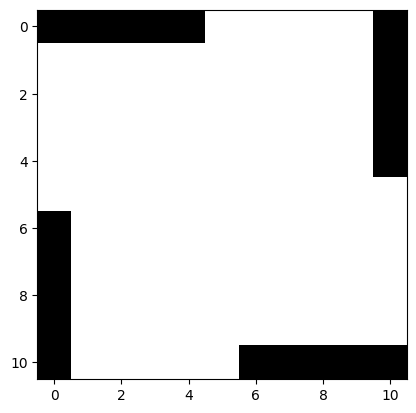

In [10]:
import matplotlib.pyplot as plt

data = train_dataset.take(1)
images, labels = list(data)[0]
images = images.numpy()
image = images[0]
print("Dimension of the CT scan is:", image.shape)
plt.imshow(np.squeeze(image[:, :, 10]), cmap="gray")


Since a CT scan has many slices, let's visualize a montage of the slices.

In [11]:

# def plot_slices(num_rows, num_columns, width, height, data):
#     """Plot a montage of 20 CT slices"""
#     data = np.rot90(np.array(data))
#     data = np.transpose(data)
#     data = np.reshape(data, (num_rows, num_columns, width, height))
#     rows_data, columns_data = data.shape[0], data.shape[1]
#     heights = [slc[0].shape[0] for slc in data]
#     widths = [slc.shape[1] for slc in data[0]]
#     fig_width = 12.0
#     fig_height = fig_width * sum(heights) / sum(widths)
#     f, axarr = plt.subplots(
#         rows_data,
#         columns_data,
#         figsize=(fig_width, fig_height),
#         gridspec_kw={"height_ratios": heights},
#     )
#     for i in range(rows_data):
#         for j in range(columns_data):
#             axarr[i, j].imshow(data[i][j], cmap="gray")
#             axarr[i, j].axis("off")
#     plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
#     plt.show()


# Visualize montage of slices.
# 4 rows and 10 columns for 100 slices of the CT scan.
# plot_slices(2, 5, 11, 11, image[:, :, :5])

# ...existing code...
import tensorflow as tf
from keras import mixed_precision

# Disable XLA JIT and force eager execution
tf.config.optimizer.set_jit(False)
tf.config.experimental_run_functions_eagerly(True)
mixed_precision.set_global_policy("float32")

print("GPUs:", tf.config.list_physical_devices("GPU"))
# ...existing code...

Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Define a 3D convolutional neural network

To make the model easier to understand, we structure it into blocks.
The architecture of the 3D CNN used in this example
is based on [this paper](https://arxiv.org/abs/2007.13224).

In [12]:
# ...existing code...
def get_model(width=11, height=11, depth=11):
    inputs = keras.Input((width, height, depth, 1))

    x = layers.Conv3D(64, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPool3D(2)(x)
    x = layers.LayerNormalization(axis=-1)(x)

    x = layers.Conv3D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool3D(2)(x)
    x = layers.LayerNormalization(axis=-1)(x)

    x = layers.Conv3D(128, 3, padding="same", activation="relu")(x)
    x = layers.MaxPool3D(2)(x)
    x = layers.LayerNormalization(axis=-1)(x)

    x = layers.Conv3D(256, 3, padding="same", activation="relu")(x)
    x = layers.LayerNormalization(axis=-1)(x)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs, name="3dcnn")
# ...existing code...


# Build model.
model = get_model(width=11, height=11, depth=11)
model.summary()

2025-12-22 13:28:25.449660: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:40] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykern/cuda_nvcc
  
  /usr/local/cuda
  /opt/cuda
  /home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/platform/../../cuda
  /home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/platform/../../../../../..
  /home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/platform/../../../../../../..
  .
You can choose the search directory by setting xla_gpu_cuda_

Model: "3dcnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11, 11, 11, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 11, 11, 11, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 5, 5, 5, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 5, 5, 5, 64)    │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 5, 5, 5, 64)    │       110,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 2, 2, 2, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 2, 2, 2, 64)    │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 2, 2, 2, 128)   │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 1, 1, 1, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 1, 1, 1, 128)   │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 1, 1, 1, 256)   │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 1, 1, 1, 256)   │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,351,873 (5.16 MB)

 Trainable params: 1,351,873 (5.16 MB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [13]:
# Custom Keras metrics and per-epoch sklearn metrics callback
import tensorflow as tf
from tensorflow import keras

# Brier Score metric (mean squared error between probabilities and labels)
class BrierScore(tf.keras.metrics.Metric):
    def __init__(self, name="brier_score", **kwargs):
        super().__init__(name=name, **kwargs)
        self.se_sum = self.add_weight(name="se_sum", initializer="zeros")
        self.n = self.add_weight(name="n", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        # Ensure same shape (probabilities)
        se = tf.reduce_sum(tf.square(y_pred - y_true))
        n = tf.cast(tf.size(y_true), tf.float32)
        self.se_sum.assign_add(se)
        self.n.assign_add(n)

    def result(self):
        return tf.math.divide_no_nan(self.se_sum, self.n)

    def reset_states(self):
        self.se_sum.assign(0.0)
        self.n.assign(0.0)

# F1 Score metric (binary, threshold 0.5)
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name="f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_hat = tf.cast(y_pred >= 0.5, tf.float32)
        tp = tf.reduce_sum(y_hat * y_true)
        fp = tf.reduce_sum(y_hat * (1.0 - y_true))
        fn = tf.reduce_sum((1.0 - y_hat) * y_true)
        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        two_tp = 2.0 * self.tp
        denom = two_tp + self.fp + self.fn
        return tf.math.divide_no_nan(two_tp, denom)

    def reset_states(self):
        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)

# Sklearn metrics printed after each epoch on validation set
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

class SklearnEpochMetrics(keras.callbacks.Callback):
    def __init__(self, x_val, y_val):
        super().__init__()
        self.x_val = x_val
        self.y_val = y_val.astype(int)

    def on_epoch_end(self, epoch, logs=None):
        # Prepare validation input (add channel dim)
        x_val_in = np.expand_dims(self.x_val, axis=-1)
        with tf.device("/CPU:0"):
            preds = self.model.predict(x_val_in, verbose=0)
        # Extract positive class probabilities
        if preds.ndim == 2:
            pos_probs = preds[:, -1]
        else:
            pos_probs = preds.squeeze()
        y_pred = (pos_probs >= 0.5).astype(int)
        y_true = self.y_val

        metrics = {}
        metrics["accuracy"] = accuracy_score(y_true, y_pred)
        metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
        metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
        metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
        metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
        metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0, 1])
        metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        report = classification_report(y_true, y_pred, digits=4)

        print("\n[Epoch {}] Sklearn metrics:".format(epoch + 1))
        print(
            " ".join([f"{k}={v:.4f}" for k, v in metrics.items()])
        )
        print("Confusion matrix:\n", cm)
        print("Classification report:\n", report)


In [15]:
# Compile model.
initial_learning_rate = 0.0001
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, decay_steps=100000, decay_rate=0.96, staircase=True
)
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="roc_auc", curve="ROC"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
        BrierScore(name="brier_score"),
        F1Score(name="f1"),
    ],
    run_eagerly=True,
)

# Define callbacks.
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "3d_image_classification.keras", save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(monitor="val_acc", patience=15)

# Train the model, doing validation at the end of each epoch
epochs = 10
# Instantiate sklearn metrics callback (prints after each epoch)
sklearn_metrics_cb = SklearnEpochMetrics(x_val, y_val)
with tf.device("/CPU:0"):
    model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        shuffle=True,
        verbose=2,
        callbacks=[checkpoint_cb, early_stopping_cb, sklearn_metrics_cb],
    )


Epoch 1/10


/home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(



[Epoch 1] Sklearn metrics:
accuracy=0.9277 precision=0.9277 recall=1.0000 f1=0.9625 mcc=0.0000 roc_auc=0.5797 pr_auc=0.9495 log_loss=0.2608 brier_score=0.0673
Confusion matrix:
 [[    0  1627]
 [    0 20863]]
Classification report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1627
           1     0.9277    1.0000    0.9625     20863

    accuracy                         0.9277     22490
   macro avg     0.4638    0.5000    0.4812     22490
weighted avg     0.8605    0.9277    0.8928     22490

44978/44978 - 10566s - 235ms/step - acc: 0.9276 - brier_score: 0.1356 - f1: 0.9625 - loss: 0.2649 - pr_auc: 0.9262 - precision: 0.9276 - recall: 1.0000 - roc_auc: 0.4934 - val_acc: 0.9277 - val_brier_score: 0.1346 - val_f1: 0.9625 - val_loss: 0.2608 - val_pr_auc: 0.9281 - val_precision: 0.9277 - val_recall: 1.0000 - val_roc_auc: 0.5004
Epoch 2/10


/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/p


[Epoch 2] Sklearn metrics:
accuracy=0.9277 precision=0.9277 recall=1.0000 f1=0.9625 mcc=0.0000 roc_auc=0.4903 pr_auc=0.9272 log_loss=0.2597 brier_score=0.0671
Confusion matrix:
 [[    0  1627]
 [    0 20863]]
Classification report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1627
           1     0.9277    1.0000    0.9625     20863

    accuracy                         0.9277     22490
   macro avg     0.4638    0.5000    0.4812     22490
weighted avg     0.8605    0.9277    0.8928     22490

44978/44978 - 10061s - 224ms/step - acc: 0.9276 - brier_score: 0.1349 - f1: 0.9625 - loss: 0.2620 - pr_auc: 0.9276 - precision: 0.9276 - recall: 1.0000 - roc_auc: 0.5015 - val_acc: 0.9277 - val_brier_score: 0.1342 - val_f1: 0.9625 - val_loss: 0.2597 - val_pr_auc: 0.9277 - val_precision: 0.9277 - val_recall: 1.0000 - val_roc_auc: 0.5000
Epoch 3/10


...

/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/p


[Epoch 9] Sklearn metrics:
accuracy=0.9277 precision=0.9277 recall=1.0000 f1=0.9625 mcc=0.0000 roc_auc=0.5000 pr_auc=0.9277 log_loss=0.2598 brier_score=0.0671
Confusion matrix:
 [[    0  1627]
 [    0 20863]]
Classification report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1627
           1     0.9277    1.0000    0.9625     20863

    accuracy                         0.9277     22490
   macro avg     0.4638    0.5000    0.4812     22490
weighted avg     0.8605    0.9277    0.8928     22490

44978/44978 - 9855s - 219ms/step - acc: 0.9276 - brier_score: 0.1346 - f1: 0.9625 - loss: 0.2612 - pr_auc: 0.9270 - precision: 0.9276 - recall: 1.0000 - roc_auc: 0.4959 - val_acc: 0.9277 - val_brier_score: 0.1342 - val_f1: 0.9625 - val_loss: 0.2597 - val_pr_auc: 0.9277 - val_precision: 0.9277 - val_recall: 1.0000 - val_roc_auc: 0.5000
Epoch 10/10


/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025-12-23 17:20:13.03804


[Epoch 10] Sklearn metrics:
accuracy=0.9277 precision=0.9277 recall=1.0000 f1=0.9625 mcc=0.0000 roc_auc=0.3755 pr_auc=0.9117 log_loss=0.2597 brier_score=0.0671
Confusion matrix:
 [[    0  1627]
 [    0 20863]]
Classification report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1627
           1     0.9277    1.0000    0.9625     20863

    accuracy                         0.9277     22490
   macro avg     0.4638    0.5000    0.4812     22490
weighted avg     0.8605    0.9277    0.8928     22490

44978/44978 - 10367s - 230ms/step - acc: 0.9276 - brier_score: 0.1346 - f1: 0.9625 - loss: 0.2611 - pr_auc: 0.9278 - precision: 0.9276 - recall: 1.0000 - roc_auc: 0.5009 - val_acc: 0.9277 - val_brier_score: 0.1342 - val_f1: 0.9625 - val_loss: 0.2597 - val_pr_auc: 0.9277 - val_precision: 0.9277 - val_recall: 1.0000 - val_roc_auc: 0.5000


/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


It is important to note that the number of samples is very small (only 200) and we don't
specify a random seed. As such, you can expect significant variance in the results. The full dataset
which consists of over 1000 CT scans can be found [here](https://www.medrxiv.org/content/10.1101/2020.05.20.20100362v1). Using the full
dataset, an accuracy of 83% was achieved. A variability of 6-7% in the classification
performance is observed in both cases.

## Visualizing model performance

Here the model accuracy and loss for the training and the validation sets are plotted.
Since the validation set is class-balanced, accuracy provides an unbiased representation
of the model's performance.

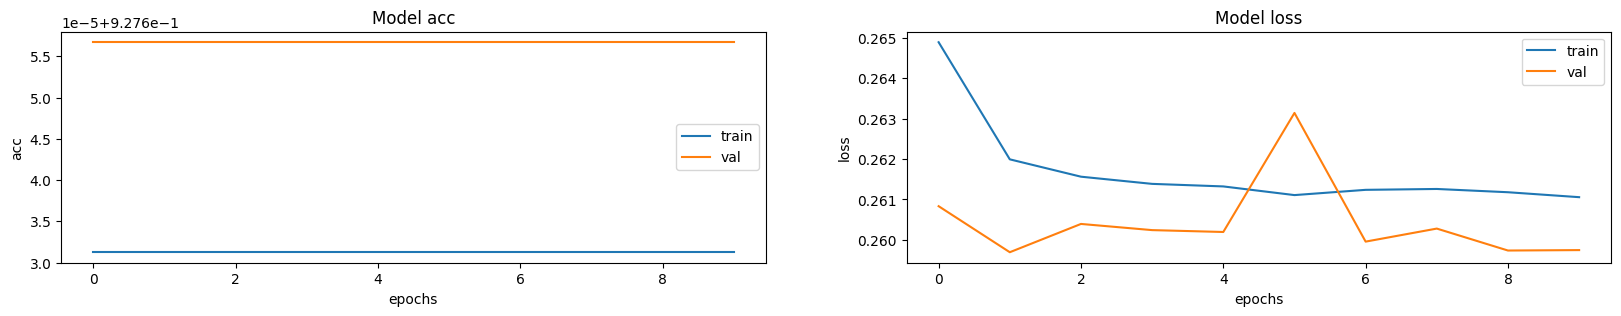

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(20, 3))
ax = ax.ravel()

for i, metric in enumerate(["acc", "loss"]):
    ax[i].plot(model.history.history[metric])
    ax[i].plot(model.history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

## Make predictions on a single CT scan

In [17]:
# Load best weights.
model.load_weights("3d_image_classification.keras")
# with tf.device("/CPU:0"):
#   prediction = model.predict(np.expand_dims(x_val[0], axis=0))[0]
# scores = [1 - prediction[0], prediction[0]]

# class_names = ["normal", "abnormal"]
# for score, name in zip(scores, class_names):
#     print(
#         "This model is %.2f percent confident that CT scan is %s"
#         % ((100 * score), name)
#     )

## Classification Metrics (scikit-learn)
We compute standard binary classification metrics on the validation set:
- Accuracy, Balanced Accuracy
- Precision, Recall, F1 (binary)
- ROC-AUC, Average Precision (PR-AUC)
- Confusion Matrix, Classification Report
- Log Loss, Brier Score
- Matthews Correlation Coefficient (MCC), Cohen's Kappa

In [18]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
x_val_in = np.expand_dims(x_val, axis=-1)
with tf.device("/CPU:0"):
  preds = model.predict(x_val_in)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = y_val.astype(int)

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

  1/703 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step

/home/vscode/.local/lib/python3.9/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


703/703 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step
Sklearn binary metrics:
accuracy: 0.9277
precision: 0.9277
recall: 1.0000
f1: 0.9625
mcc: 0.0000
roc_auc: 0.4903
pr_auc: 0.9272
log_loss: 0.2597
brier_score: 0.0671

Confusion matrix:
 [[    0  1627]
 [    0 20863]]

Classification report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1627
           1     0.9277    1.0000    0.9625     20863

    accuracy                         0.9277     22490
   macro avg     0.4638    0.5000    0.4812     22490
weighted avg     0.8605    0.9277    0.8928     22490



/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
